In [1]:
from dataset import *
from rmap import *
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score
from itertools import combinations
from scipy.stats import spearmanr
from sklearn.semi_supervised import LabelPropagation
from copy import deepcopy
import matplotlib.font_manager as fm

## Relation between threshold and remaining edges

In [2]:
# Threshold and the number of pilot BBs that can be selected with our clustering method
suzuki_data = SuzukiDataset(for_conventional_models=False, keepPhBr=False, from_notebook=True)
relation_dict = {
    "Target Core":[],
    "Threshold":[],
    "Portion of retained edges":[],
}
for target_core in [0, 1, 3, 7, 8]:
    rmap = ReactivityMap(
        source_core_inds=None, 
        target_core_ind=target_core, 
        test_bb_inds=[], 
        dataset=suzuki_data
    )
    rmap.get_similarity_matrix()
    sim_mat = rmap.similarity_matrix
    print("Target core", target_core+1)
    for threshold in np.arange(0, 1, 0.05):
        adj = rmap._similarity_matrix_to_adjacency_matrix(sim_mat, threshold)
        portion_retained = np.sum(adj > 0) / len(adj.flatten())
        relation_dict["Target Core"].append(target_core+1)
        relation_dict["Threshold"].append(threshold)
        relation_dict["Portion of retained edges"].append(portion_retained)
        print("    ", round(threshold, 2), len(rmap.select_first_batch(n_select=12, similarity_threshold=threshold)))
    print()

Target core 1
     0.0 1
     0.05 1
     0.1 1
     0.15 1
     0.2 1
     0.25 1
     0.3 1
     0.35 1
     0.4 1
     0.45 1
     0.5 1
     0.55 1
     0.6 2
     0.65 2
     0.7 5
     0.75 8
     0.8 12
     0.85 12
     0.9 12
     0.95 12

Target core 2
     0.0 1
     0.05 1
     0.1 1
     0.15 1
     0.2 1
     0.25 1
     0.3 1
     0.35 1
     0.4 1
     0.45 1
     0.5 1
     0.55 1
     0.6 2
     0.65 3
     0.7 5
     0.75 6
     0.8 12
     0.85 12
     0.9 12
     0.95 12

Target core 4
     0.0 1
     0.05 1
     0.1 1
     0.15 1
     0.2 1
     0.25 1
     0.3 1
     0.35 1
     0.4 1
     0.45 1
     0.5 1
     0.55 1
     0.6 3
     0.65 3
     0.7 4
     0.75 6
     0.8 12
     0.85 12
     0.9 12
     0.95 12

Target core 8
     0.0 1
     0.05 1
     0.1 1
     0.15 1
     0.2 1
     0.25 1
     0.3 1
     0.35 1
     0.4 1
     0.45 1
     0.5 1
     0.55 1
     0.6 2
     0.65 4
     0.7 5
     0.75 7
     0.8 12
     0.85 12
     0.9 12
     0.95 12

Targ

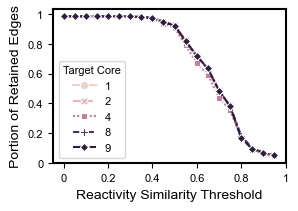

In [3]:
# Relationship between remaining edges and the similarity threshold
fig, ax = plt.subplots(figsize=(3,2))
sns.lineplot(data=pd.DataFrame(relation_dict), x="Threshold", y="Portion of retained edges", hue="Target Core", style="Target Core", markers=True)
ax.set_xlabel("Reactivity Similarity Threshold", fontdict={"size":10, "family":"arial"})
ax.set_ylabel("Portion of Retained Edges", fontdict={"size":10, "family":"arial"})
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
ax.set_yticklabels([0, 0.2, 0.4, 0.6, 0.8, 1], fontdict={"size":8, "family":"arial"})
ax.set_xticklabels([0, 0.2, 0.4, 0.6, 0.8, 1], fontdict={"size":8, "family":"arial"})
for axis in ["top", "bottom", "left", "right"]:
    ax.spines[axis].set_linewidth(1.5)
ax.legend(prop=fm.FontProperties(family="Arial", size=8), loc="lower left", title="Target Core", title_fontproperties=fm.FontProperties(family="Arial", size=8))
plt.savefig("../figures/SI/edges_vs_threshold.svg", dpi=300, bbox_inches="tight", format="svg")

## Relation between predictivity and network form (which is threshold-dependent) and number of pilot BBs

For this experiment, we fix the threshold to a high value (0.82) to ensure 12 pilot BBs can be sampled.
As pilot BBs are selected in an accumulating fashion due to the clustering method's iterative nature, we simply evaluate predictivity on the 57 remaining BBs, excluding the 12 pilot BBs.

In [3]:
# The accumulating fashion of the pilot BB selection can be checked through running this code snippet
suzuki_data = SuzukiDataset(for_conventional_models=False, keepPhBr=False, from_notebook=True)
neighbors_dict = {}
for target_core in [0, 1, 3, 7, 8]:
    rmap = ReactivityMap(source_core_inds=None, target_core_ind=target_core, test_bb_inds=[], dataset=suzuki_data)
    for n_select in [4, 6, 8, 10, 12]:
        selected_bb_inds = rmap.select_first_batch(n_select=n_select)
        print(selected_bb_inds)
    neighbors_dict[target_core] = rmap.neighbors_inds
    print()


[23, 27, 66, 33]
[23, 27, 66, 33, 67, 62]
[23, 27, 66, 33, 67, 62, 40, 49]
[23, 27, 66, 33, 67, 62, 40, 49, 25, 19]
[23, 27, 66, 33, 67, 62, 40, 49, 25, 19, 47, 55]

[53, 21, 44, 18]
[53, 21, 44, 18, 58, 62]
[53, 21, 44, 18, 58, 62, 14, 50]
[53, 21, 44, 18, 58, 62, 14, 50, 19, 10]
[53, 21, 44, 18, 58, 62, 14, 50, 19, 10, 32, 68]

[2, 27, 52, 62]
[2, 27, 52, 62, 67, 58]
[2, 27, 52, 62, 67, 58, 13, 25]
[2, 27, 52, 62, 67, 58, 13, 25, 1, 36]
[2, 27, 52, 62, 67, 58, 13, 25, 1, 36, 10, 39]

[8, 52, 20, 44]
[8, 52, 20, 44, 56, 58]
[8, 52, 20, 44, 56, 58, 6, 61]
[8, 52, 20, 44, 56, 58, 6, 61, 50, 25]
[8, 52, 20, 44, 56, 58, 6, 61, 50, 25, 15, 68]

[52, 11, 2, 62]
[52, 11, 2, 62, 67, 58]
[52, 11, 2, 62, 67, 58, 14, 25]
[52, 11, 2, 62, 67, 58, 14, 25, 10, 50]
[52, 11, 2, 62, 67, 58, 14, 25, 10, 50, 36, 32]



11
12
14
12
14


/var/folders/05/jxqj_ld96mx38n9knzsjp58c0000gn/T/ipykernel_13517/3746790101.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(np.arange(0, 16, 5), fontdict={"size":8, "family":"arial"})


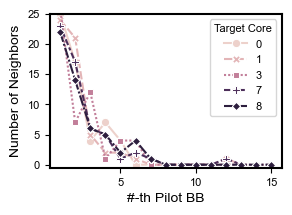

In [7]:
# Looking at the neighbors of each pilot BBs, selected for all cores
neigh_dict_to_plot = {
    "#-th Pilot BB":[],
    "Target Core":[],
    "Number of Neighbors":[]
}
for i in [0,1,3,7,8]:
    for j, neigh_list in enumerate(neighbors_dict[i]) :
        neigh_dict_to_plot["Target Core"].append(i)
        neigh_dict_to_plot["#-th Pilot BB"].append(j+1)
        neigh_dict_to_plot["Number of Neighbors"].append(len(neigh_list))
    print(j)

fig, ax = plt.subplots(figsize=(3,2))
sns.lineplot(neigh_dict_to_plot, x="#-th Pilot BB", y="Number of Neighbors", style="Target Core", hue="Target Core", markers=True)
ax.set_ylim(-0.5, 25)
ax.set_yticks(np.arange(0, 26, 5))
ax.set_ylabel("Number of Neighbors", fontdict={"size":10, "family":"arial"})
ax.set_yticklabels(np.arange(0, 26, 5), fontdict={"size":8, "family":"arial"})
ax.set_xticklabels(np.arange(0, 16, 5), fontdict={"size":8, "family":"arial"})
ax.set_xlabel("#-th Pilot BB", fontdict={"size":10, "family":"arial"})
for axis in ["top", "bottom", "left", "right"]:
    ax.spines[axis].set_linewidth(1.5)
ax.legend(prop=fm.FontProperties(family="Arial", size=8), loc="upper right", title="Target Core", title_fontproperties=fm.FontProperties(family="Arial", size=8))

plt.savefig("../figures/SI/pilotBB_neighbors.svg", dpi=300, bbox_inches="tight", format="svg")

In [8]:
suzuki_data = SuzukiDataset(for_conventional_models=False, keepPhBr=False, from_notebook=True)

score_dict = {}
for target_core in [0, 1, 3, 7, 8]:
    rmap2 = ReactivityMap(source_core_inds=None, target_core_ind=target_core, test_bb_inds=[], dataset=suzuki_data)

    scores = np.zeros((5, 5))
    binarized_target = deepcopy(rmap2.target_reactivity_array)
    binarized_target[binarized_target<=1] = 0
    binarized_target[binarized_target==2] = 1
    for a, threshold in enumerate([0.5, 0.6, 0.7, 0.8, 0.85]):
        rmap = ReactivityMap(source_core_inds=None, target_core_ind=target_core, test_bb_inds=[], dataset=suzuki_data)
        max_selected_bb_inds = rmap.select_first_batch(n_select=12, similarity_threshold=0.82) # Getting the 12 pilot BBs using a fixed high threshold
        remaining_bb_inds = [bb_ind for bb_ind in range(len(rmap.train_bb_inds)) if bb_ind not in max_selected_bb_inds]
        adj = rmap._similarity_matrix_to_adjacency_matrix(
            rmap.similarity_matrix, threshold
        )
        adj += 0.001
        def _kernel(X, y):
            return adj
        for b, n_select in enumerate([4, 6, 8, 10, 12]):
            X_ohe = np.identity(len(rmap.train_bb_inds))
            y = -1 * np.ones(len(rmap.train_bb_inds))
            y[max_selected_bb_inds[:n_select]] = rmap.target_reactivity_array[
                max_selected_bb_inds[:n_select]
            ]
            y[y==1] = 0 # Only highest yield class as positive
            y[y==2] = 1
            lp = LabelPropagation(kernel=_kernel, n_jobs=-1)
            lp.fit(X_ohe, y)
            lp_pred_proba = lp.predict_proba(X_ohe)[:, -1]
            score = average_precision_score(
                binarized_target[remaining_bb_inds], lp_pred_proba[remaining_bb_inds]
            )
            scores[a, b] = score
        
    score_dict[target_core] = scores

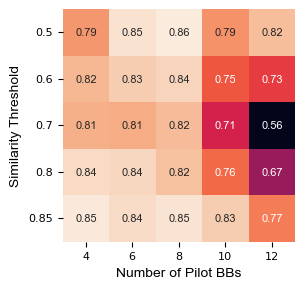

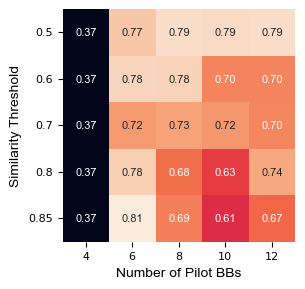

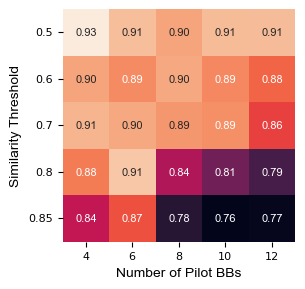

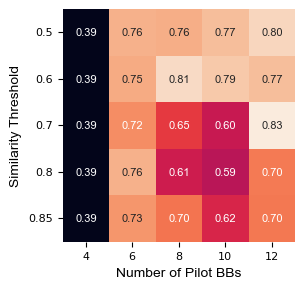

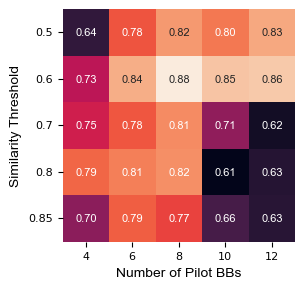

In [10]:
for i in [0, 1, 3, 7, 8]:
    fig, ax = plt.subplots(figsize=(3,4))
    sns.heatmap(
        score_dict[i], 
        yticklabels=[0.5, 0.6, 0.7, 0.8, 0.85], 
        xticklabels=[4, 6, 8, 10, 12],
        annot=True, fmt=".2f",
        cbar=False, annot_kws={"fontsize": 8, "fontfamily": "arial"},
        square=True
        # vmax=1, vmin=0.5
    )
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=8)
    ax.set_xlabel("Number of Pilot BBs", fontdict={"size":10, "family":"arial"})
    ax.set_ylabel("Similarity Threshold", fontdict={"size":10, "family":"arial"})
    plt.savefig(f"../figures/SI/FigureSX_core{i+1}_auprc_vs_threshold_pilotBB.svg", dpi=300, bbox_inches="tight", format="svg")